### high_value_orders_classification

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

In [3]:
from sklearn.ensemble import RandomForestClassifier

In [4]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [5]:
original_df = pd.read_csv("../dataset/original_dataset/ecommerce_orders_dataset.csv")

In [6]:
df = original_df.copy()

In [7]:
print(df.shape)

(30000, 41)


In [8]:
df.head()

,Order_ID,Customer_ID,Order_Date,Year,Month,Day,Day_Of_Week,Quarter,Customer_Age,Customer_Gender,...,Delivery_Days,Order_Status,Returned,Review_Rating,Customer_Lifetime_Value,Profit_Margin_Percent,Profit_Amount,Season,Holiday_Season,High_Value_Order
0,615717,CUST007322,2023-01-01,2023,1,1,Sunday,1,32,Male,...,2,Delivered,No,4.4,2144.92,23.10,15.75,Winter,No,No
1,626919,CUST004717,2023-01-01,2023,1,1,Sunday,1,50,Male,...,9,Delivered,No,4.1,817.17,8.57,3.32,Winter,No,No
2,615781,CUST004415,2023-01-01,2023,1,1,Sunday,1,61,Male,...,2,Delivered,No,5.0,541.16,29.72,45.67,Winter,No,No
3,621747,CUST004114,2023-01-01,2023,1,1,Sunday,1,34,Male,...,6,Returned,Yes,3.4,700.49,25.22,75.25,Winter,No,No
4,625881,CUST000145,2023-01-01,2023,1,1,Sunday,1,37,Male,...,8,Delivered,No,3.6,2133.77,24.64,26.06,Winter,No,No


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 41 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Order_ID                 30000 non-null  int64  
 1   Customer_ID              30000 non-null  str    
 2   Order_Date               30000 non-null  str    
 3   Year                     30000 non-null  int64  
 4   Month                    30000 non-null  int64  
 5   Day                      30000 non-null  int64  
 6   Day_Of_Week              30000 non-null  str    
 7   Quarter                  30000 non-null  int64  
 8   Customer_Age             30000 non-null  int64  
 9   Customer_Gender          30000 non-null  str    
 10  Country                  30000 non-null  str    
 11  City                     30000 non-null  str    
 12  Customer_Segment         30000 non-null  str    
 13  Product_ID               30000 non-null  str    
 14  Product_Category         30000 no

In [10]:
print(df["High_Value_Order"].value_counts())

High_Value_Order
No     22499
Yes     7501
Name: count, dtype: int64


In [11]:
print(df["High_Value_Order"].value_counts(normalize=True)*100)

High_Value_Order
No     74.996667
Yes    25.003333
Name: proportion, dtype: float64


In [12]:
df.isnull().sum()

Order_ID                   0
Customer_ID                0
Order_Date                 0
Year                       0
Month                      0
Day                        0
Day_Of_Week                0
Quarter                    0
Customer_Age               0
Customer_Gender            0
Country                    0
City                       0
Customer_Segment           0
Product_ID                 0
Product_Category           0
Product_Subcategory        0
Brand                      0
Unit_Price                 0
Quantity                   0
Discount_Percent           0
Discount_Amount            0
Coupon_Used                0
Shipping_Cost              0
Tax_Amount                 0
Order_Amount               0
Payment_Method             0
Device_Type                0
Traffic_Source             0
Membership_Status          0
Shipping_Method            0
Warehouse_Region           0
Delivery_Days              0
Order_Status               0
Returned                   0
Review_Rating 

In [13]:
df.drop(
    columns=[
        "Order_ID",
        "Customer_ID",
        "Product_ID",
        "Order_Amount",
        "Profit_Amount",
        "Tax_Amount"
    ],
    inplace=True
)

In [14]:
X = df.drop("High_Value_Order", axis=1)
y =df["High_Value_Order"]

In [15]:
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical Columns:", len(categorical_cols))
print("Numerical Columns", len(numerical_cols))

Categorical Columns: 20
Numerical Columns 14


C:\Users\srava\AppData\Local\Temp\ipykernel_10260\142581708.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()


In [16]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_cols
        )
    ],
    remainder="passthrough"
)

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

In [18]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),

        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42
            )
        )
    ]
)

In [19]:
rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['No','Yes']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](34,)","['Order_Date','Year','Month',...,'Profit_Margin_Percent','Season', 'Holiday_Season']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,34
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthro

In [20]:
y_pred = rf_model.predict(X_test)

In [21]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9575


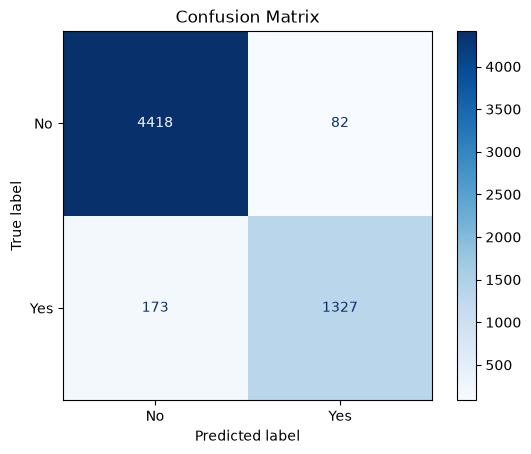

In [22]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=rf_model.classes_
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

In [23]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          No       0.96      0.98      0.97      4500
         Yes       0.94      0.88      0.91      1500

    accuracy                           0.96      6000
   macro avg       0.95      0.93      0.94      6000
weighted avg       0.96      0.96      0.96      6000



## Experiment 1 



In [24]:
rf = rf_model.named_steps["classifier"]

In [25]:
feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()

In [26]:
importance = rf.feature_importances_

In [27]:
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

In [28]:
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(20)

,Feature,Importance
1593,remainder__Unit_Price,0.179048
1600,remainder__Customer_Lifetime_Value,0.155956
1497,cat__Product_Category_Electronics,0.106325
1596,remainder__Discount_Amount,0.085265
1594,remainder__Quantity,0.037620
1503,cat__Product_Subcategory_Accessories,0.022362
1526,cat__Product_Subcategory_Mobile,0.020683
1523,cat__Product_Subcategory_Laptop,0.019766
1522,cat__Product_Subcategory_Headphones,0.017117
1499,cat__Product_Category_Groceries,0.016173


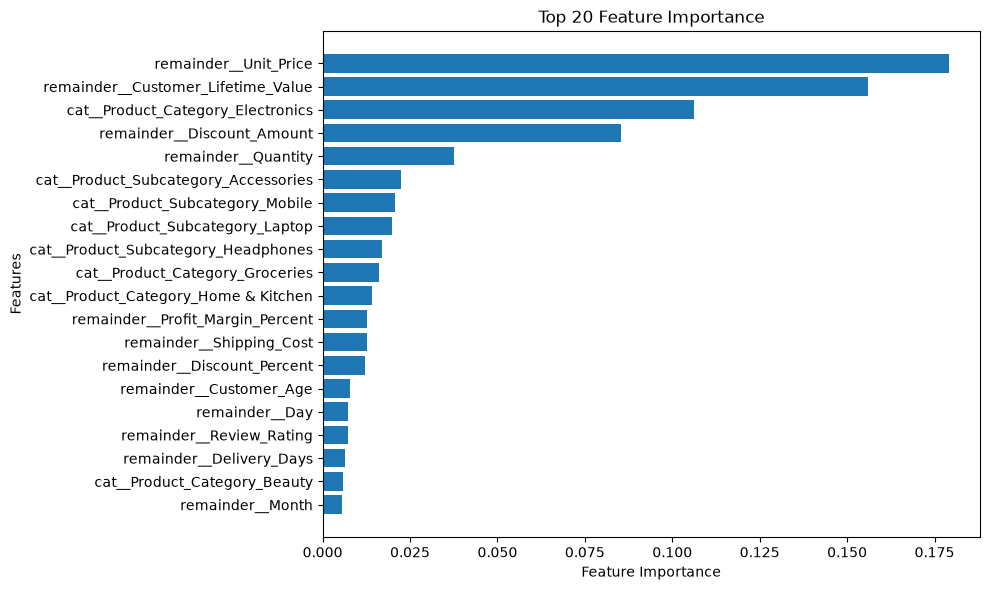

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(
    importance_df["Feature"].head(20),
    importance_df["Importance"].head(20)
)

plt.gca().invert_yaxis()

plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Top 20 Feature Importance")

plt.tight_layout()

# Optional: Save the graph
plt.savefig("feature_importance_exp2.png", dpi=300, bbox_inches="tight")

plt.show()

In [30]:
original_df[["Order_Amount", "High_Value_Order"]].head()

,Order_Amount,High_Value_Order
0,68.20,No
1,38.73,No
2,153.66,No
3,298.37,No
4,105.75,No


In [31]:
original_df.groupby("High_Value_Order")["Order_Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
High_Value_Order,,,,,,,,
No,22499.0,144.255416,94.195631,6.67,67.40,120.19,205.365,388.17
Yes,7501.0,1083.114437,826.429620,388.19,521.36,778.83,1353.810,10314.27
